# Landmark-based Registration

## Introduction
In this exercise, you will implement 3D rigid and affine image registration based on anatomical landmarks. You will work with a T1-weighted and a T2-weighted MRI scan of the same patient, where the patient is lying in a different position in the scanner between the two image acquisition (for the purpose of this exercise, the movement is simulated).

### Instructions for your report
Your report should be structured as follows:
* **Introduction**: a short summary of what your report is about, perhaps with a recap of some of the equations you'll be using in your solution.
* **Task 1, ..., 5**: for each specific task listed below, your code (in code cells), your results (as figures) as well as explanations of what is computed and what is shown in the figures (in Markdown cells). 
* **Conclusion**: a short summary of your findings.

This introduction should **not** be part of your report.

### Input data and code hints
Import Python libraries:

In [2]:
import matplotlib.pyplot as plt
#%matplotlib notebook
%matplotlib ipympl
plt.ion()
import numpy as np
np.set_printoptions( suppress=True )
import nibabel as nib
import scipy

Read the two 3D scans you'll be working with in this exercise:

In [3]:
# Load T1 and T2 data
T1_fileName = 'IXI014-HH-1236-T1.nii.gz'
T2_fileName = 'IXI014-HH-1236-T2_moved.nii.gz'
T1 = nib.load( T1_fileName )
T2 = nib.load( T2_fileName )
T1_data = T1.get_fdata()
T2_data = T2.get_fdata()

Below is code to define a simple interactive viewer class that can be used to visualize 2D cross-sections of a 3D array along three orthogonal directions. It takes a 3D volume as input and shows the location a "linked cursor" in all three cross-sections.

In [4]:
class Viewer:
    def __init__(self, data ):
        self.fig, self.ax = plt.subplots()
        self.data = data
        self.dims = self.data.shape
        self.position = np.round( np.array( self.dims ) / 2 ).astype( int )
        self.draw()
        self.fig.canvas.mpl_connect( 'button_press_event', self )
        self.fig.show()

    def __call__(self, event):
        print( 'button pressed' )
        if event.inaxes is None: return
      
        x, y = round( event.xdata ), round( event.ydata )

        #
        if ( x > (self.dims[0]-1) ) and ( y <= (self.dims[1]-1) ): return # lower-right quadrant
          
        #
        if x < self.dims[0]:
          self.position[ 0 ] = x
        else:
          self.position[ 1 ] = x - self.dims[0]
        
        if y < self.dims[1]:
          self.position[ 1 ] = y
        else:
          self.position[ 2 ] = y -self.dims[1]
        
        print( f"  voxel index: {self.position}" )
        print( f"  intensity: {self.data[ self.position[0], self.position[1], self.position[2] ]}" )

        self.draw()

    def draw( self ):
        #
        # Layout on screen is like this:
        #
        #     ^            ^
        #  Z  |         Z  |
        #     |            |
        #     ----->        ---->  
        #       X             Y
        #     ^
        #  Y  |
        #     |
        #     ----->  
        #       X
        #
        dims = self.dims
        position = self.position
        
        xySlice = self.data[ :, :, position[ 2 ] ]
        xzSlice = self.data[ :, position[ 1 ], : ]
        yzSlice = self.data[ position[ 0 ], :, : ]
        
        kwargs = dict( vmin=self.data.min(), vmax=self.data.max(), 
                       origin='lower', 
                       cmap='gray',
                       picker=True )

        self.ax.clear()

        self.ax.imshow( xySlice.T, 
                        extent=( 0, dims[0]-1, 
                                 0, dims[1]-1 ), 
                        **kwargs )
        self.ax.imshow( xzSlice.T, 
                        extent=( 0, dims[0]-1, 
                                 dims[1], dims[1]+dims[2]-1 ), 
                        **kwargs )
        self.ax.imshow( yzSlice.T, extent=( dims[0], dims[0]+dims[1]-1, 
                                            dims[1], dims[1]+dims[2]-1 ), 
                        **kwargs )

        color = 'g'
        self.ax.plot( (0, dims[0]-1), (position[1], position[1]), color )
        self.ax.plot( (0, dims[0]+dims[1]-1), (dims[1]+position[2], dims[1]+position[2]), color )
        self.ax.plot( (position[0], position[0]), (0, dims[1]+dims[2]-1), color )
        self.ax.plot( (dims[0]+position[1], dims[0]+position[1]), (dims[1]+1, dims[1]+dims[2]-1), color )

        self.ax.set( xlim=(1, dims[0]+dims[1]), ylim=(0, dims[1]+dims[2]) )

        self.ax.text( dims[0] + dims[1]/2, dims[1]/2, 
                      f"voxel index: {position}",  
                      horizontalalignment='center', verticalalignment='center' )
  
        self.ax.axis( False )

        self.fig.canvas.draw()

The code below shows how to visualize the T1-weigthed and the T2-weighted volumes with this viewer class. The initial location of the cursor is in the middle of the volume in each case. It can be changed by clicking on one of the cross-sections. The viewer also displays the voxel index $\mathbf{v}$ of the cursor. Play around and try to understand what the Viewer() class does.

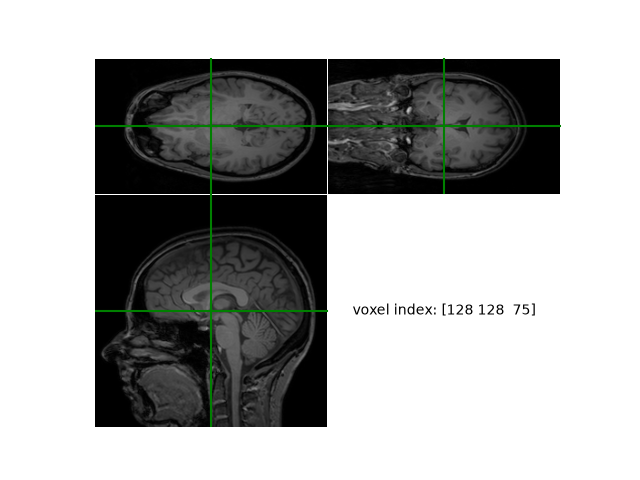

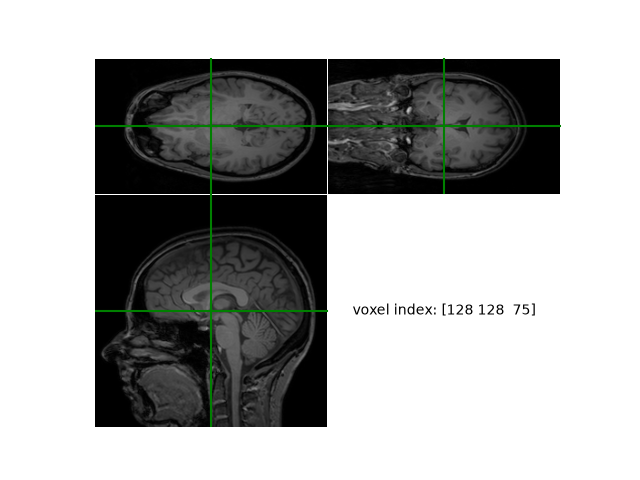

In [6]:

T1_viewer = Viewer( T1_data )

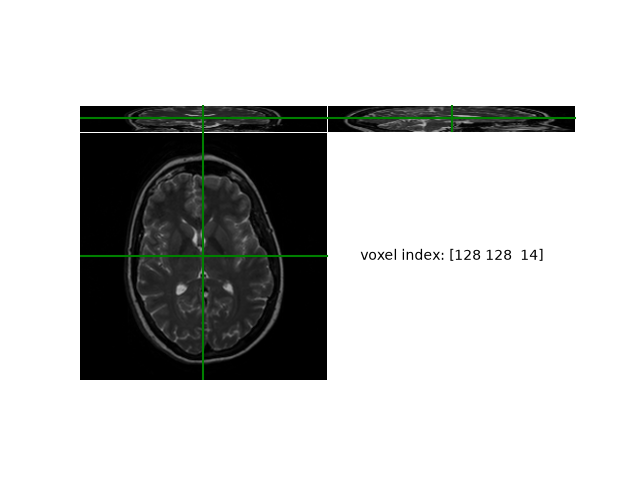

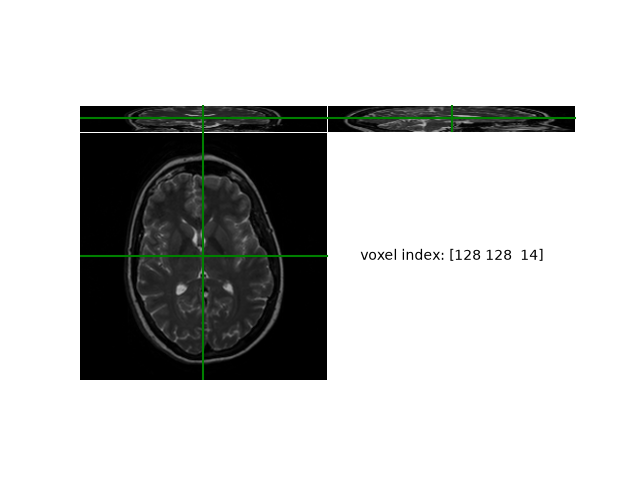

In [7]:

T2_viewer = Viewer( T2_data )

### Task 1: Coordinate Systems

Familiarize yourself with the concept of coordinate systems. In your report, explain why we need to differentiate between "voxel coordinates/indices" $\mathbf{v}$ and "world coordinates" $\mathbf{x}$. Why does the T2-weighted volume look so compressed in the viewer? For the enthusiastic student: calculate the voxel size in each dataset.

The world coordinate system used in both the T1-weighted and the T2-weighted scan follows the RAS convention. Equipped with this information, determine the voxel index $\mathbf{v}$ of the center of the left eye of the patient in the T1-weighted scan. Do the same for the T2-weighted scan.
 
> ***Hints:***
> 
> - The affine voxel-to-world matrix of the T1-weighted scan is given by
>
>        T1.affine
>
> 
> - In nibabel, the RAS convention is used (see bottom of https://nipy.org/nibabel/coordinate_systems.html)



In [8]:

print("T1 affine:\n", T1.affine)
print("T2 affine:\n", T2.affine)

T1 affine:
 [[   0.01506851   -0.01498772    1.19969177  -89.9808197 ]
 [  -0.92914075    0.12376414    0.02165389  117.73051453]
 [   0.12400278    0.92917383    0.01646696 -121.56955719]
 [   0.            0.            0.            1.        ]]
T2 affine:
 [[ -0.83986628  -0.24726994  -1.11736882 169.03053284]
 [ -0.22234981   0.86080861  -0.71725279 -27.57552719]
 [ -0.22885627   0.07110596   4.79742765 -51.29128265]
 [  0.           0.           0.           1.        ]]


In [9]:
voxel_size_T1 = np.linalg.norm(T1.affine[:3, :3], axis=0)
voxel_size_T2 = np.linalg.norm(T2.affine[:3, :3], axis=0)
print("T1 voxel size (mm):", voxel_size_T1)
print("T2 voxel size (mm):", voxel_size_T2)

T1 voxel size (mm): [0.93750001 0.93749997 1.20000017]
T2 voxel size (mm): [0.89843753 0.8984375  4.97777829]


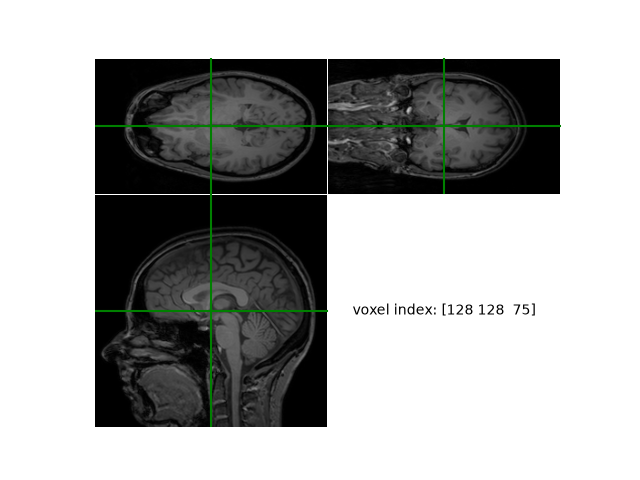

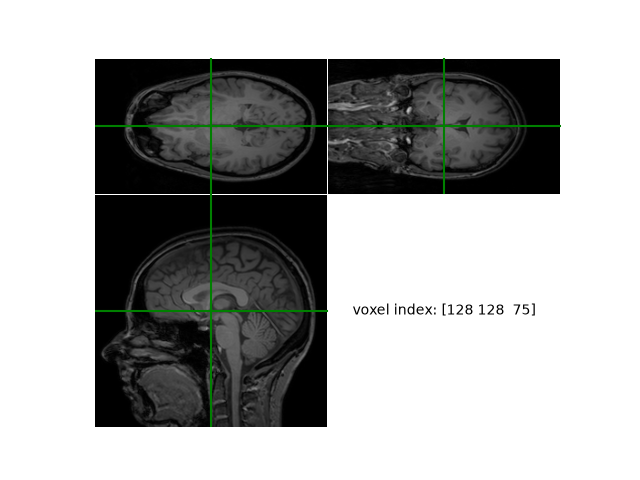

In [14]:
viewer1 = Viewer(T1_data)   # run this cell first — a figure appears

In [31]:
v1 = np.array([59, 111, 54, 1])   # your clicked voxel index, homogeneous
x_world = T1.affine @ v1
print("x_world =", x_world[:3])

x_world = [-25.97205898  77.81834038 -10.22588233]


In [33]:
v2_hom = np.linalg.inv(T2.affine) @ x_world
v2 = v2_hom[:3]
print("v2 =", v2)

v2 = [162.22168131 175.74824965  13.69360925]


In [43]:
v2_real = np.array([88, 201, 8])
v2_computed = np.array([162.22168131, 175.74824965, 13.69360925])

discrepancy_voxels = np.linalg.norm(v2_real - v2_computed)
print("Discrepancy (voxels):", discrepancy_voxels)

# also express in mm, using T2's voxel size, for a physically meaningful number
discrepancy_mm = discrepancy_voxels_per_axis = (v2_real - v2_computed) * voxel_size_T2
print("Per-axis discrepancy (mm):", discrepancy_mm)

Discrepancy (voxels): 78.60614517016857
Per-axis discrepancy (mm): [-66.68354408  22.68711954 -28.34152454]


### Task 2: Resample the T2-weighted scan to the image grid of the T1-weighted scan

In this task you should resample the T2-weighted scan to the image grid of the T1-weighted scan, i.e., create a new 3D volume that has the same size as the T1-weighted volume, but that contains interpolated T2-weighted intensities instead. In particular, for each voxel index $\mathbf{v}_{T1}$ in the T1-weighted image grid, you should compute the corresponding voxel index $\mathbf{v}_{T2}$ in the T2-weighted volume as follows (see section 2.1 in the book):
$$
\begin{pmatrix} \mathbf{ v_{T2}} \\ 1 \end{pmatrix} = \mathbf{M}_{T2}^{-1} \cdot \mathbf{M}_{T1} \cdot \begin{pmatrix} \mathbf{ v_{T1}} \\ 1 \end{pmatrix}
.
$$
At the location $\mathbf{v}_{T2}$, you should then use cubic B-spline interpolation to determine the intensity in the T2-weighted scan, and store it at index $\mathbf{v}_{T1}$ in the newly created image.

Once you have created a new volume like this, visualize it overlaid on the T1-weighted volume as follows:
    
    Viewer( T2_data_resampled / T2_data_resampled.max() + T1_data / T1_data.max() )

> ***Hints:***
> - you can create a coordinate grid in 3D with the function
> 
>        V1,V2,V3 = np.meshgrid( np.arange( T1_data.shape[0] ), 
>                                np.arange( T1_data.shape[1] ), 
>                                np.arange( T1_data.shape[2] ), indexing='ij' )
>   
>
> - the following SciPy function interpolates the T2-weighted volume at voxel coordinates $(1.1,2.2,3.3)^T$ 
> and $(6.6,7.7,8.8)^T$ using cubic interpolation:   
>
>        scipy.ndimage.map_coordinates( T2_data, np.array( [ [1.1,2.2,3.3], [6.6,7.7,8.8] ] ).T )
>

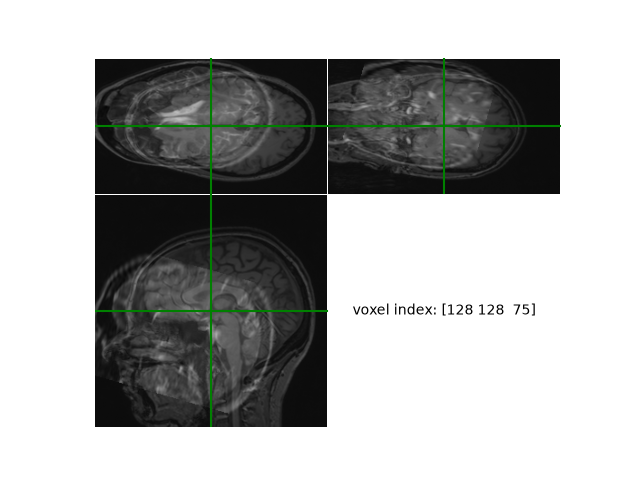

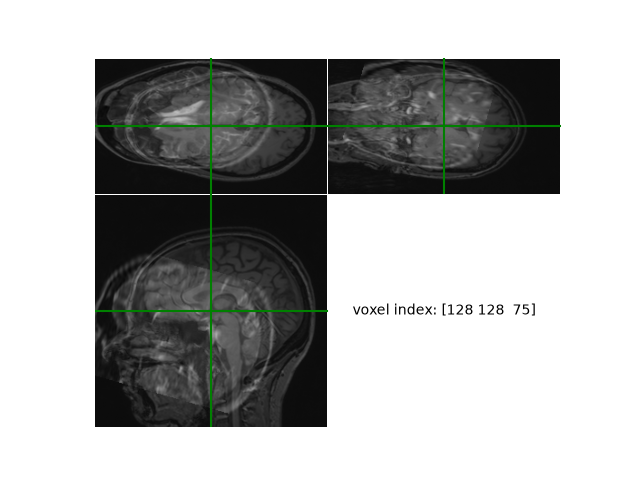

In [34]:
V1, V2, V3 = np.meshgrid(
    np.arange(T1_data.shape[0]),
    np.arange(T1_data.shape[1]),
    np.arange(T1_data.shape[2]),
    indexing='ij'
)

M = np.linalg.inv(T2.affine) @ T1.affine   # combined T1-voxel -> T2-voxel matrix

ones = np.ones_like(V1)
coords_T1_hom = np.stack([V1, V2, V3, ones])            # shape (4, nx, ny, nz)
coords_T1_hom_flat = coords_T1_hom.reshape(4, -1)         # shape (4, N)

coords_T2_hom_flat = M @ coords_T1_hom_flat                # shape (4, N)
coords_T2 = coords_T2_hom_flat[:3] / coords_T2_hom_flat[3]  # drop homogeneous row → (3, N)


T2_values = scipy.ndimage.map_coordinates(T2_data, coords_T2, order=3)

T2_data_resampled = T2_values.reshape(T1_data.shape)

Viewer(T2_data_resampled / T2_data_resampled.max() + T1_data / T1_data.max())

### Task 3: Collect corresponding landmarks

Using the viewer class, record the voxel coordinates $\mathbf{v_{T1}}$ and $\mathbf{v_{T2}}$ of at least five corresponding landmarks in the T1- and the T2-weighted volumes, respectively. List them in your report, and explain why you picked them. 

> ***Hint:***
> - Avoid picking landmarks that are very close to each other or that all lie approximately in the same 2D plane.
> - You can double-check which landmarks you've selected as follows:
>         T1_viewer = Viewer( T1_data )
>         T1_viewer.position = ( 20, 30, 40 )
>         T1_viewer.draw()
> 


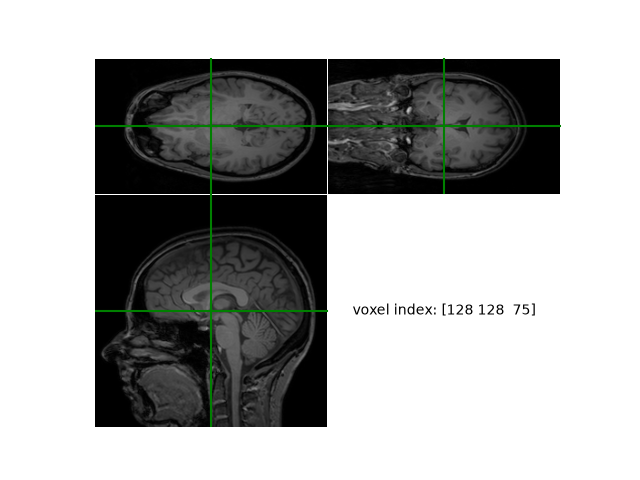

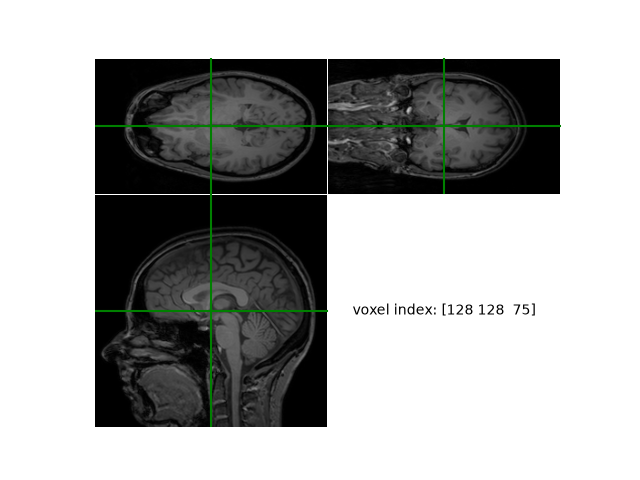

In [36]:
T1_viewer = Viewer(T1_data)


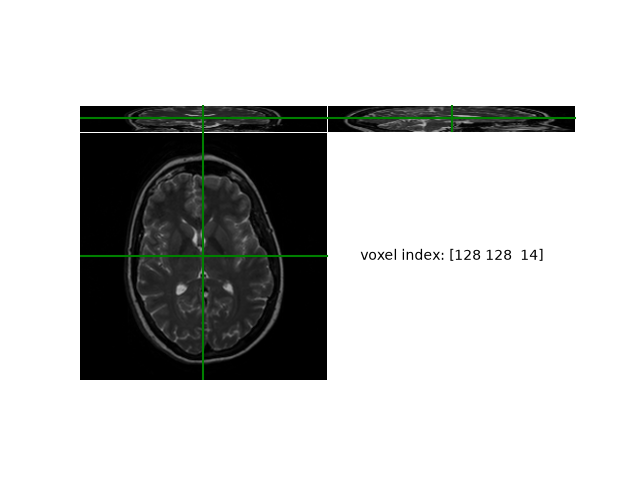

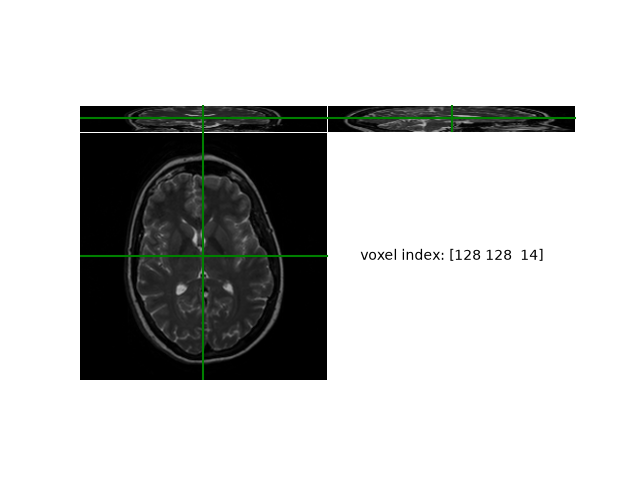

In [37]:
T2_viewer = Viewer(T2_data)

In [38]:
landmarks_T1 = np.array([
    [59, 111, 54],    
    [11, 81, 80],
    [156, 81, 19],
    [156, 133, 77],
    [47, 168, 77],
])

landmarks_T2 = np.array([
    [ 87, 201, 8 ],    
    [119, 236, 6],
    [54, 110, 6],
    [126, 120, 16],
    [120, 223, 20],
])

### Task 4: Perform affine landmark-based registration 

Using the landmarks you recorded in the previous task, compute the parameters of the 3D affine transformation that brings the landmarks in the T1-weighted image closest to the corresponding ones in the T2-weighted image. For this purpose, use Equation (2.8) in the book.

Once you've determined the affine transformation, register to two images by resampling the T2-weighted image to the image grid of the T1-weighted image, and overlay the two images as in Task 2. To map voxel coordinates $\mathbf{v}_T1$ to $\mathbf{v}_T2$, you'll have to use 
$$
\begin{pmatrix} \mathbf{ v_{T2}} \\ 1 \end{pmatrix} = \mathbf{M}_{T2}^{-1} \cdot \mathbf{M} \cdot \mathbf{M}_{T1} \cdot \begin{pmatrix} \mathbf{ v_{T1}} \\ 1 \end{pmatrix}
,
$$
where $\mathbf{M}$ is your $4 \times 4$ affine matrix (see book).

What happens when you increase/decrease the number of corresponding landmarks that are used in the computations? Comment.

> ***Hint:***
> - remember that the affine matrix works in *world* coordinates, so you'll have to map your landmarks to world coordinates first.
> - you can use  
>
>       np.hstack() 
>
>   to append a column of ones to an existing matrix (e.g., to construct the $\mathbf{X}$ matrix in Equation (2.8) in the book).
>

A =
 [[-0.91767547 -0.18474974 -0.24503285]
 [-0.29397214  0.8381457  -0.03988344]
 [-0.03586071  0.07758767  0.78117534]]
t = [ 21.23538644  45.17952003 -10.27998337]


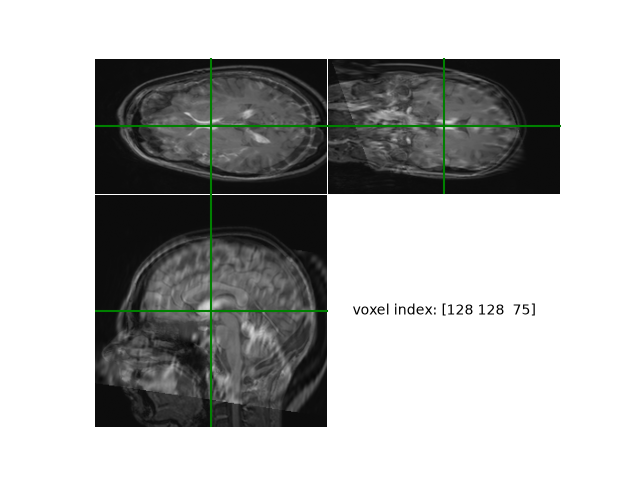

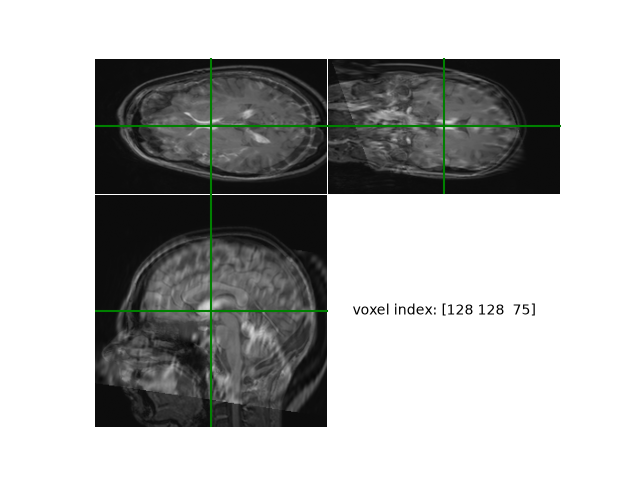

In [41]:
N = landmarks_T1.shape[0]
ones_col = np.ones((N, 1))

lm_T1_hom = np.hstack([landmarks_T1, ones_col])   # (N,4)
lm_T2_hom = np.hstack([landmarks_T2, ones_col])   # (N,4)

world_T1 = (T1.affine @ lm_T1_hom.T).T[:, :3]     # (N,3)
world_T2 = (T2.affine @ lm_T2_hom.T).T[:, :3]     # (N,3)

# --- Step 2: solve Eq. (2.8) for all 3 dimensions at once ---
X = np.hstack([ones_col, world_T1])               # (N,4): [1, x1, x2, x3]
Y = world_T2                                       # (N,3): target world coords

W = np.linalg.inv(X.T @ X) @ X.T @ Y               # (4,3)

t = W[0, :]                                        # translation, shape (3,)
A = W[1:, :].T                                      # affine matrix, shape (3,3)

print("A =\n", A)
print("t =", t)

# --- Step 3: assemble the 4x4 affine matrix M ---
M = np.eye(4)
M[:3, :3] = A
M[:3, 3] = t

# --- Step 4: resample T2 onto T1 grid using this M ---
M_full = np.linalg.inv(T2.affine) @ M @ T1.affine   # combined voxel-to-voxel matrix

coords_T2_hom_flat = M_full @ coords_T1_hom_flat    # reuse coords_T1_hom_flat from Task 2
coords_T2_affine = coords_T2_hom_flat[:3] / coords_T2_hom_flat[3]

T2_values_affine = scipy.ndimage.map_coordinates(T2_data, coords_T2_affine, order=3)
T2_data_resampled_affine = T2_values_affine.reshape(T1_data.shape)

Viewer(T2_data_resampled_affine / T2_data_resampled_affine.max() + T1_data / T1_data.max())

In [46]:
# --- Quantitative registration error (Task 4, affine, all N landmarks) ---
predicted_T2 = world_T1 @ A.T + t
residuals_affine = np.linalg.norm(predicted_T2 - world_T2, axis=1)
print("Affine per-landmark residuals (mm):", residuals_affine)
print("Affine RMS error (mm):", np.sqrt(np.mean(residuals_affine**2)))

Affine per-landmark residuals (mm): [8.54261514 2.74429533 3.52953507 1.68269091 3.95147565]
Affine RMS error (mm): 4.720395251343993


In [44]:
for n_use in [4, 5]:   # you only have 5 landmarks, so these are your two options
    X_sub = np.hstack([ones_col[:n_use], world_T1[:n_use]])
    Y_sub = world_T2[:n_use]
    W_sub = np.linalg.inv(X_sub.T @ X_sub) @ X_sub.T @ Y_sub
    t_sub, A_sub = W_sub[0,:], W_sub[1:,:].T
    print(f"n={n_use}: A=\n{A_sub}\nt={t_sub}\n")

n=4: A=
[[-1.00876305 -0.11357213 -0.07788416]
 [-0.33635894  0.87126756  0.03789772]
 [ 0.12385574 -0.04721787  0.48809044]]
t=[19.16386412 44.21555555 -6.6476971 ]

n=5: A=
[[-0.91767547 -0.18474974 -0.24503285]
 [-0.29397214  0.8381457  -0.03988344]
 [-0.03586071  0.07758767  0.78117534]]
t=[ 21.23538644  45.17952003 -10.27998337]



### Task 5: Perform rigid landmark-based registration 

Repeat Task 4, but this time using a *rigid* transformation model. Vary the number of landmarks that are used again, and comment. Which transformation model (affine or rigid) is more appropriate to use in this specific application?

> ***Hint:***
> - a singular value decomposition can be computed using
>           
>          np.linalg.svd()
>
> - the determinant of a matrix can be computed using
>    
>         np.linalg.det()
>


det(R) = 1.0
R^T R =
 [[ 1. -0.  0.]
 [-0.  1. -0.]
 [ 0. -0.  1.]]
R =
 [[ 0.0534489  -0.56041322 -0.82648668]
 [ 0.33894251  0.78871438 -0.51288166]
 [ 0.9392876  -0.25271852  0.23210378]]
t_rigid = [55.72558261 56.88898176 21.95405423]


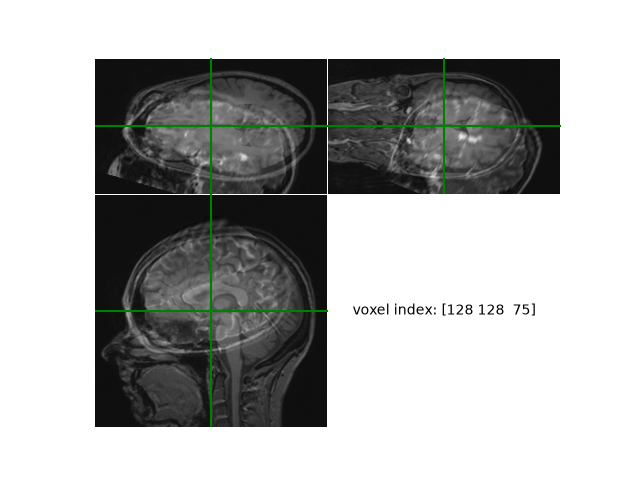

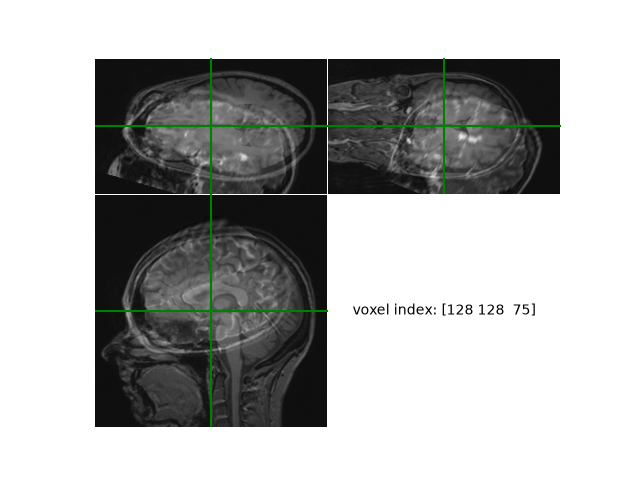

In [42]:
# --- Step 1: centroids of the landmark sets (world coords) ---
x_bar = world_T1.mean(axis=0)
y_bar = world_T2.mean(axis=0)

x_tilde = world_T1 - x_bar      # centered T1 landmarks, (N,3)
y_tilde = world_T2 - y_bar      # centered T2 landmarks, (N,3)

# --- Step 2: SVD of sum_n x_tilde_n @ y_tilde_n^T ---
H = x_tilde.T @ y_tilde         # (3,3), equals sum_n outer(x_tilde_n, y_tilde_n)
U, S, Vt = np.linalg.svd(H)
V = Vt.T

R = V @ U.T

# --- Step 3: fix reflection if det(R) = -1 ---
if np.linalg.det(R) < 0:
    V[:, -1] *= -1
    R = V @ U.T

print("det(R) =", np.linalg.det(R))     # should be +1
print("R^T R =\n", R.T @ R)              # should be ~identity
print("R =\n", R)

# --- Step 4: translation ---
t_rigid = y_bar - R @ x_bar
print("t_rigid =", t_rigid)

# --- Step 5: assemble matrix and resample T2 onto T1 grid ---
M_rigid = np.eye(4)
M_rigid[:3, :3] = R
M_rigid[:3, 3] = t_rigid

M_full_rigid = np.linalg.inv(T2.affine) @ M_rigid @ T1.affine

coords_T2_hom_flat_rigid = M_full_rigid @ coords_T1_hom_flat
coords_T2_rigid = coords_T2_hom_flat_rigid[:3] / coords_T2_hom_flat_rigid[3]

T2_values_rigid = scipy.ndimage.map_coordinates(T2_data, coords_T2_rigid, order=3)
T2_data_resampled_rigid = T2_values_rigid.reshape(T1_data.shape)

Viewer(T2_data_resampled_rigid / T2_data_resampled_rigid.max() + T1_data / T1_data.max())

In [47]:
# --- Quantitative registration error (Task 5, rigid, all N landmarks) ---
predicted_T2_rigid = world_T1 @ R.T + t_rigid
residuals_rigid = np.linalg.norm(predicted_T2_rigid - world_T2, axis=1)
print("Rigid per-landmark residuals (mm):", residuals_rigid)
print("Rigid RMS error (mm):", np.sqrt(np.mean(residuals_rigid**2)))

Rigid per-landmark residuals (mm): [19.91487143 41.62439479 22.67643801 37.95963979 36.37539495]
Rigid RMS error (mm): 32.886218383679385


In [45]:
for n_use in [4, 5]:
    x_bar_sub = world_T1[:n_use].mean(axis=0)
    y_bar_sub = world_T2[:n_use].mean(axis=0)
    x_tilde_sub = world_T1[:n_use] - x_bar_sub
    y_tilde_sub = world_T2[:n_use] - y_bar_sub
    H_sub = x_tilde_sub.T @ y_tilde_sub
    U_sub, S_sub, Vt_sub = np.linalg.svd(H_sub)
    V_sub = Vt_sub.T
    R_sub = V_sub @ U_sub.T
    if np.linalg.det(R_sub) < 0:
        V_sub[:, -1] *= -1
        R_sub = V_sub @ U_sub.T
    t_sub_rigid = y_bar_sub - R_sub @ x_bar_sub
    print(f"n={n_use}: R=\n{R_sub}\nt={t_sub_rigid}\ndet(R)={np.linalg.det(R_sub)}\n")

n=4: R=
[[-0.64055669 -0.42538354 -0.63932462]
 [ 0.11127877  0.77234308 -0.62538245]
 [ 0.75980534 -0.47173617 -0.44739337]]
t=[32.14928673 48.28933406 11.39419847]
det(R)=1.0000000000000009

n=5: R=
[[ 0.0534489  -0.56041322 -0.82648668]
 [ 0.33894251  0.78871438 -0.51288166]
 [ 0.9392876  -0.25271852  0.23210378]]
t=[55.72558261 56.88898176 21.95405423]
det(R)=1.0

